In [1]:
import monitrix
monitrix.__version__

'0.3.0.dev0'

In [2]:
from monitrix.manager import Model
from monitrix.objectdetector import yolo
from monitrix.postprocess import InclusionProperty,InclusionConfig

# モデルの生成
model = Model(
    yolo.YOLOc300(yolo.YOLOInitConfig(tracker='botsort.yaml')),
    # 後処理
    [
        #StationaryTracker(ThresholdConfig(0.80)), # トラッキング（インスタンスid割り振り）
        #ClassConfFilter(), # confフィルタ
        InclusionProperty(InclusionConfig(0)) # 包含関係
     ]
    )


In [3]:
from pathlib import Path
from monitrix.objectdetector.yolo import exResults

source = Path("../../sample_data/横切り（遅）.mp4").resolve()
source = Path("../../sample_data/PLフィルタ.mp4").resolve()
assert source.exists()

# 領域検出実行
results:list[exResults] = [r for r in model.predict(source)]


video 1/1 (frame 1/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\PL.mp4: 416x736 2 main screens, 2 oxygen%s, 2 MV L/mins, 2 VT mLs, 2 breathing rates, 4.4ms
video 1/1 (frame 2/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\PL.mp4: 416x736 2 main screens, 2 oxygen%s, 2 MV L/mins, 2 VT mLs, 2 breathing rates, 4.4ms
video 1/1 (frame 3/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\PL.mp4: 416x736 2 main screens, 2 oxygen%s, 2 MV L/mins, 2 VT mLs, 2 breathing rates, 4.4ms
video 1/1 (frame 4/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\PL.mp4: 416x736 2 main screens, 2 oxygen%s, 2 MV L/mins, 2 VT mLs, 2 breathing rates, 4.4ms
video 1/1 (frame 5/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\PL.mp4: 416x736 2 main screens, 2 oxygen%s, 2 MV L/mins, 2 VT mLs, 2 breathing rates, 4.4ms
video 1/1 (frame 6/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\PL.mp

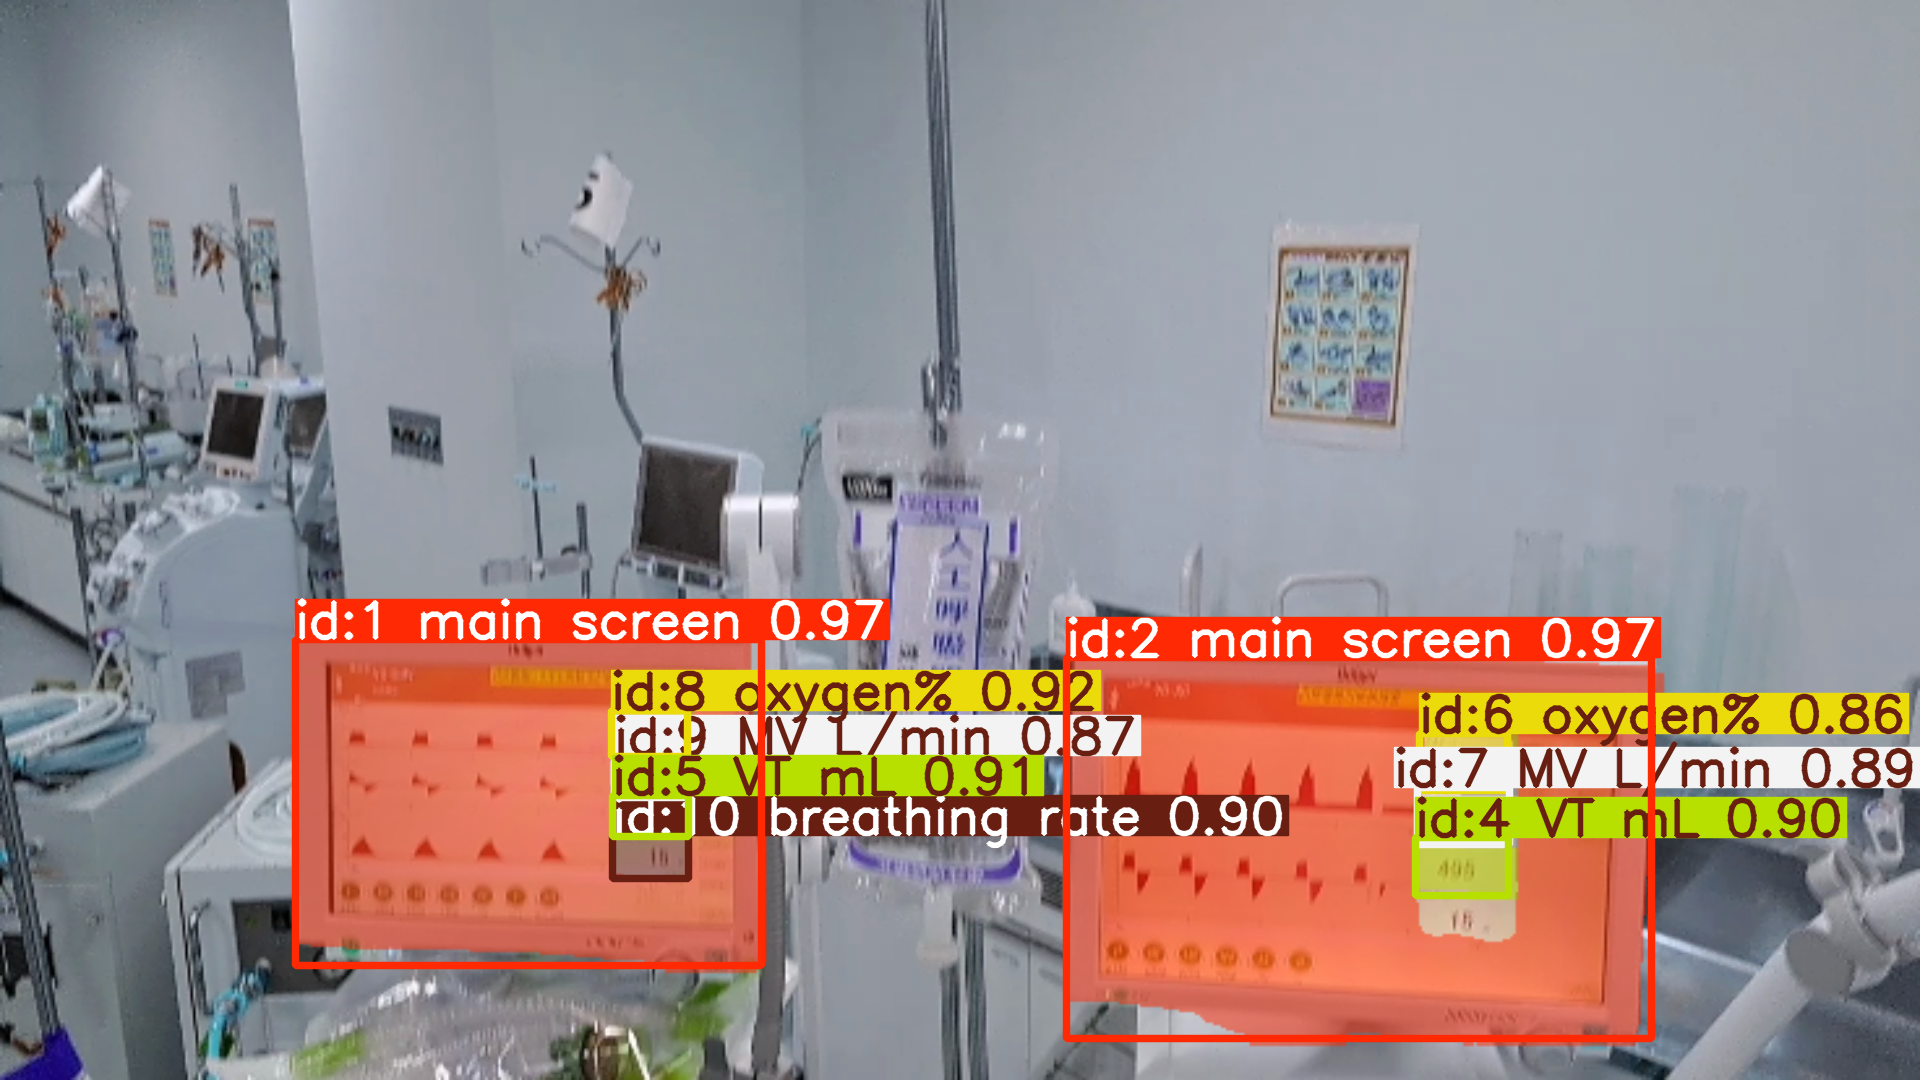

In [4]:
from PIL import Image
# 領域検出結果
Image.fromarray(results[190].plot())

In [5]:
from monitrix.numberdetector import eocr
# 数値の読み取りモデル生成
reader = eocr.EasyocrNumberReader(
    init_config=eocr.EasyocrInitConfig(
        gpu=True,
        detector=True,
        cudnn_benchmark=True),
    default_predict_conf=eocr.EasyocrPredictConfig(batch_size=16)
)

In [6]:
from monitrix.manager import ImageGroupTextReader
from monitrix.numberdetector.projective import ProjectiveMatrixCV2
from monitrix.numberdetector.geometry import coordinate_cv2jit
# 数値の読み取り
r = ImageGroupTextReader(
    reader,
    result_type=eocr.Nums,
    projecter = ProjectiveMatrixCV2,
    coordinate = coordinate_cv2jit,
    perspective = False,
    aspect_ratio = 4/3,
    bottom_margin_rate = 0.02,
    batched=False
)

k = 190
g = r.apply(results[k])#4,962,64
g.aggregate

monitrix.objectdetector.yolo.Agg object with attributes:

base_box_id: tensor([1., 2., 2., 1., 1., 1., 1., 2., 2.], dtype=torch.float64)
box_conf: tensor([0.9683, 0.9697, 0.8975, 0.9116, 0.9175, 0.8740, 0.9048, 0.8896, 0.8623], dtype=torch.float64)
cls: tensor([0., 0., 3., 3., 1., 2., 4., 2., 1.], dtype=torch.float64)
conf: tensor([   nan,    nan, 0.2020, 0.3093,    nan, 0.1056,    nan, 0.2876,    nan], dtype=torch.float64)
data: tensor([[1.9000e+02, 1.0000e+00, 1.0000e+00, 1.0000e+00, 9.6826e-01, 0.0000e+00,        nan,        nan],
        [1.9000e+02, 1.0000e+00, 2.0000e+00, 2.0000e+00, 9.6973e-01, 0.0000e+00,        nan,        nan],
        [1.9000e+02, 0.0000e+00, 2.0000e+00, 4.0000e+00, 8.9746e-01, 3.0000e+00, 2.0200e-01, 4.0000e+00],
        [1.9000e+02, 0.0000e+00, 1.0000e+00, 5.0000e+00, 9.1162e-01, 3.0000e+00, 3.0927e-01, 0.0000e+00],
        [1.9000e+02, 0.0000e+00, 1.0000e+00, 8.0000e+00, 9.1748e-01, 1.0000e+00,        nan,        nan],
        [1.9000e+02, 0.0000e+00, 1.0

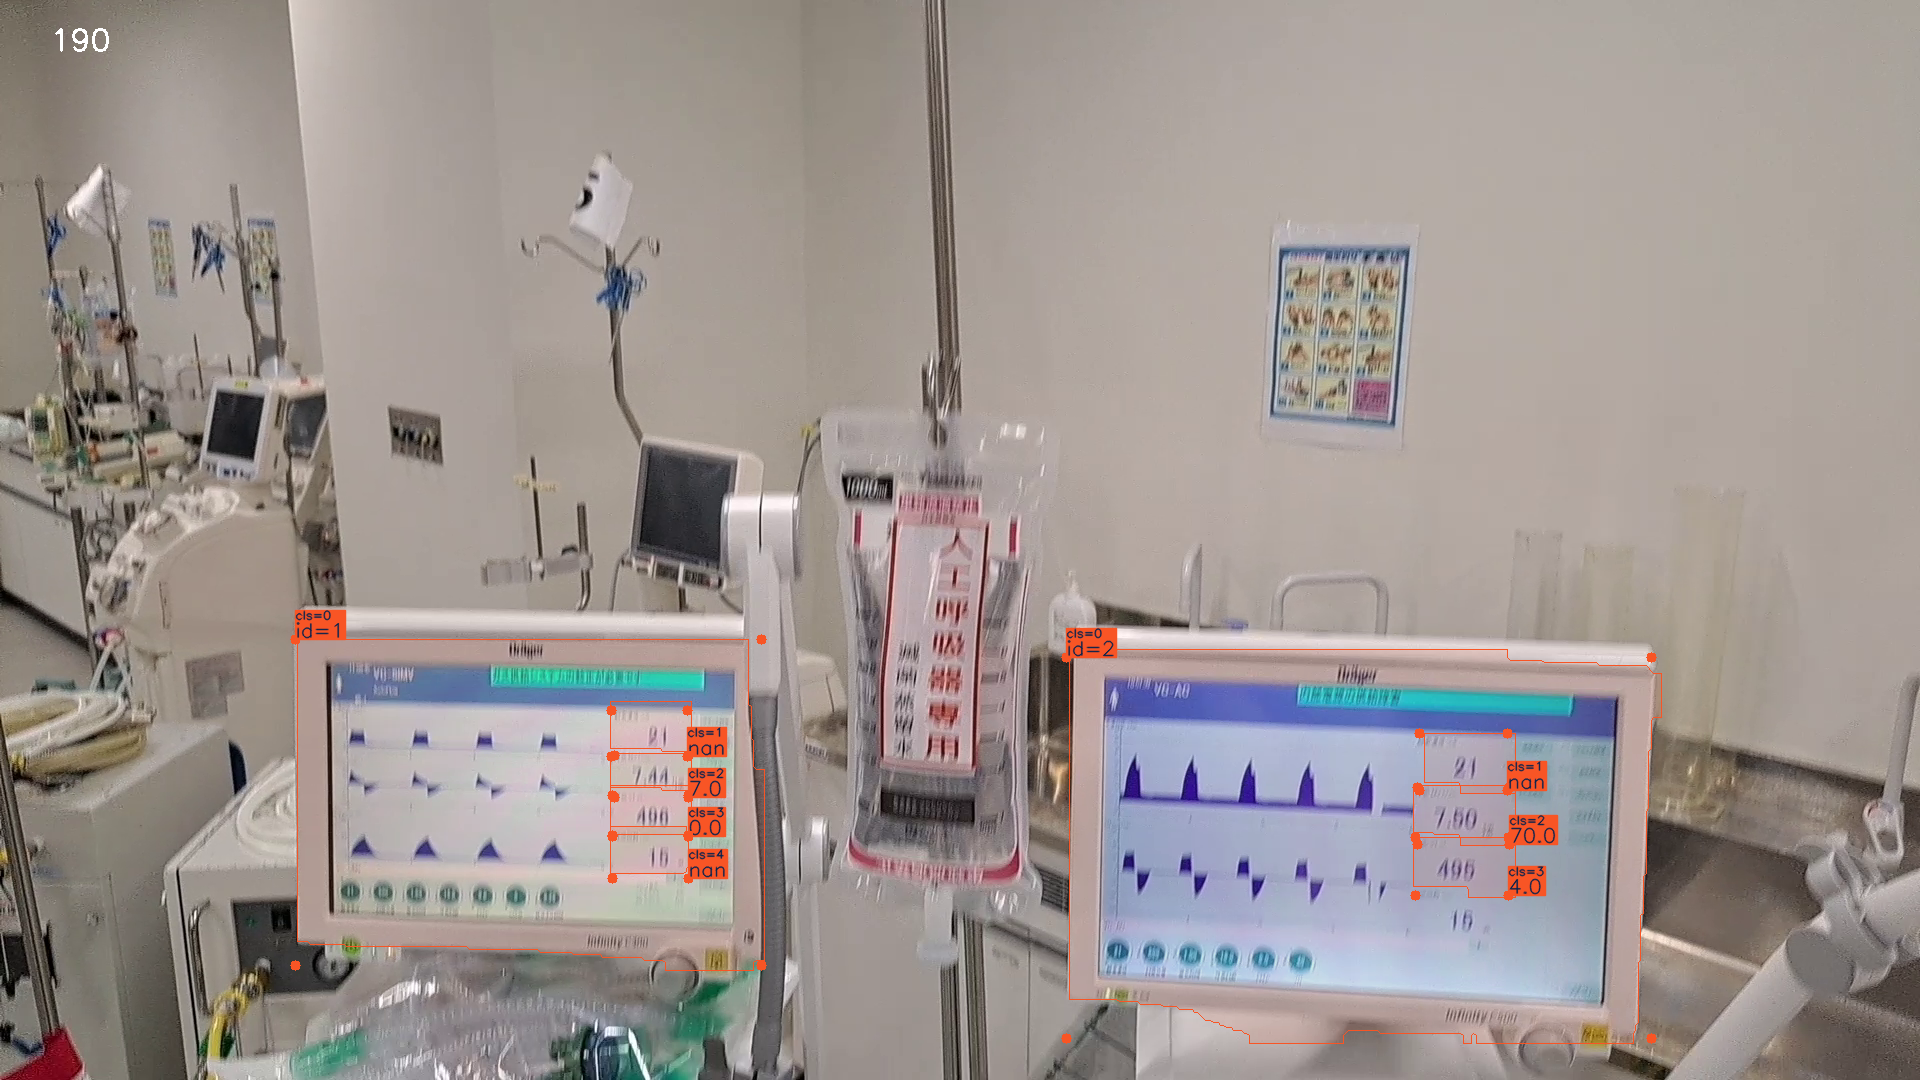

In [7]:
from monitrix.draw import plot
Image.fromarray(plot(results[k],cvt_rgb=True))

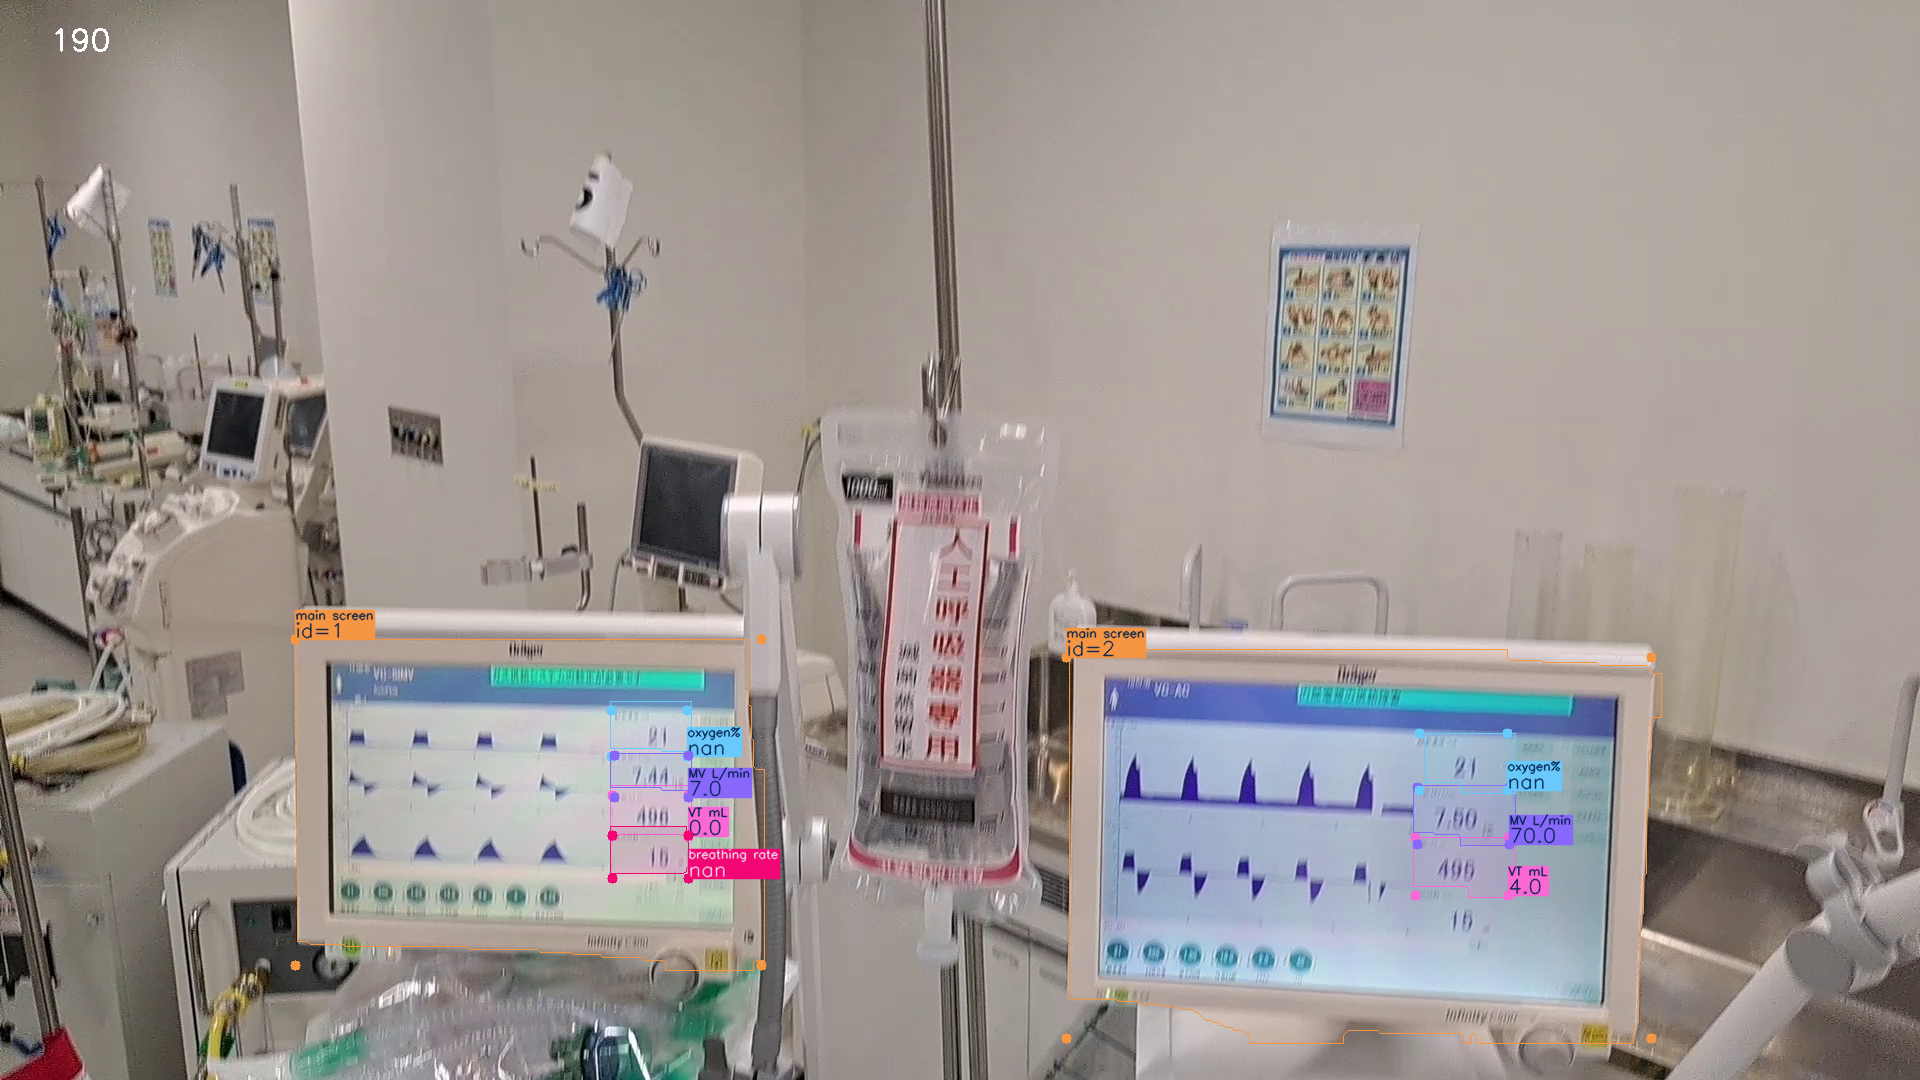

In [8]:
from monitrix.draw import plot
preset_colors = {
    0:("#F69642","#01204E"),
    1:("#68C9FA","#01204E"),
    2:("#8868FA","#01204E"),
    3:("#FA68D5","#01204E"),
    4:("#F10674","#EDE1E9"),
}
preset_classnames = {
    0:"main screen",
    1:"oxygen%",
    2:"MV L/min",
    3:"VT mL",
    4:"breathing rate",
}

Image.fromarray(plot(results[k],class_names=preset_classnames,colors=preset_colors,cvt_rgb=True))

---

In [7]:
from pathlib import Path
from monitrix.objectdetector.yolo import exResults
from monitrix.manager import Model, ImageGroupTextReader
from monitrix.objectdetector import yolo
from monitrix.postprocess import InclusionProperty,InclusionConfig
from tqdm import tqdm
from monitrix.numberdetector.projective import ProjectiveMatrixCV2
from monitrix.numberdetector.geometry import coordinate_cv2jit
from monitrix.numberdetector import eocr

source = Path("../../sample_data/横切り（遅）.mp4").resolve()
source = Path("../../sample_data/PLフィルタ.mp4").resolve()

assert source.exists()

model = Model(
    yolo.YOLOc300(
        yolo.YOLOInitConfig(
            tracker='botsort.yaml',
            # default_config = yolo.YOLOPredictConfig(save=True)
            ),
        ),
    # 後処理
    [
        InclusionProperty(InclusionConfig(0)) # 包含関係
     ]
    )

reader = eocr.EasyocrNumberReader(
    init_config=eocr.EasyocrInitConfig(
        gpu=True,
        detector=True,# Falseに対応していない
        cudnn_benchmark=True),
    default_predict_conf=eocr.EasyocrPredictConfig(batch_size=16)
)

results:list[exResults] = [r for r in model.predict(source)]

r = ImageGroupTextReader(
    reader,
    result_type=eocr.Nums,
    projecter = ProjectiveMatrixCV2,
    coordinate = coordinate_cv2jit,
    perspective = False,
    aspect_ratio = 4/3,
    bottom_margin_rate = 0.02,
    batched=True
)

with tqdm(total=len(results), desc="read number", leave=True) as pbar:
    for k, result in enumerate(results):
        try:
            r.apply(result)
        except Exception as e:
            print(k)
            print(e)
        finally:
            pbar.update()



video 1/1 (frame 1/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\PL.mp4: 416x736 2 main screens, 2 oxygen%s, 2 MV L/mins, 2 VT mLs, 2 breathing rates, 14.1ms
video 1/1 (frame 2/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\PL.mp4: 416x736 2 main screens, 2 oxygen%s, 2 MV L/mins, 2 VT mLs, 2 breathing rates, 14.1ms
video 1/1 (frame 3/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\PL.mp4: 416x736 2 main screens, 2 oxygen%s, 2 MV L/mins, 2 VT mLs, 2 breathing rates, 14.1ms
video 1/1 (frame 4/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\PL.mp4: 416x736 2 main screens, 2 oxygen%s, 2 MV L/mins, 2 VT mLs, 2 breathing rates, 14.1ms
video 1/1 (frame 5/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\PL.mp4: 416x736 2 main screens, 2 oxygen%s, 2 MV L/mins, 2 VT mLs, 2 breathing rates, 14.1ms
video 1/1 (frame 6/347) C:\Users\ARISAKA\Box\BoxNotes\\\monitrix\v3\monitrix\sample_data\

read number: 100%|██████████| 347/347 [01:24<00:00,  4.11it/s]


[<Figure size 1200x800 with 8 Axes>, <Figure size 1200x800 with 8 Axes>]

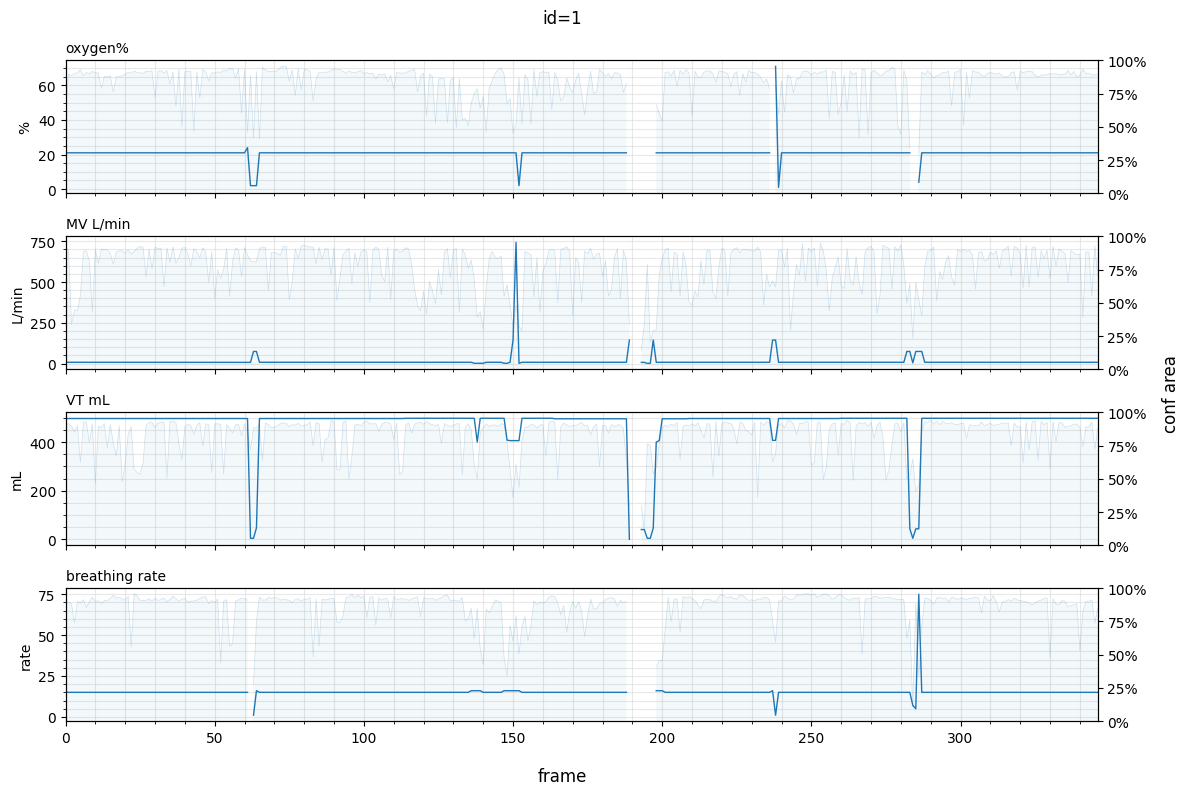

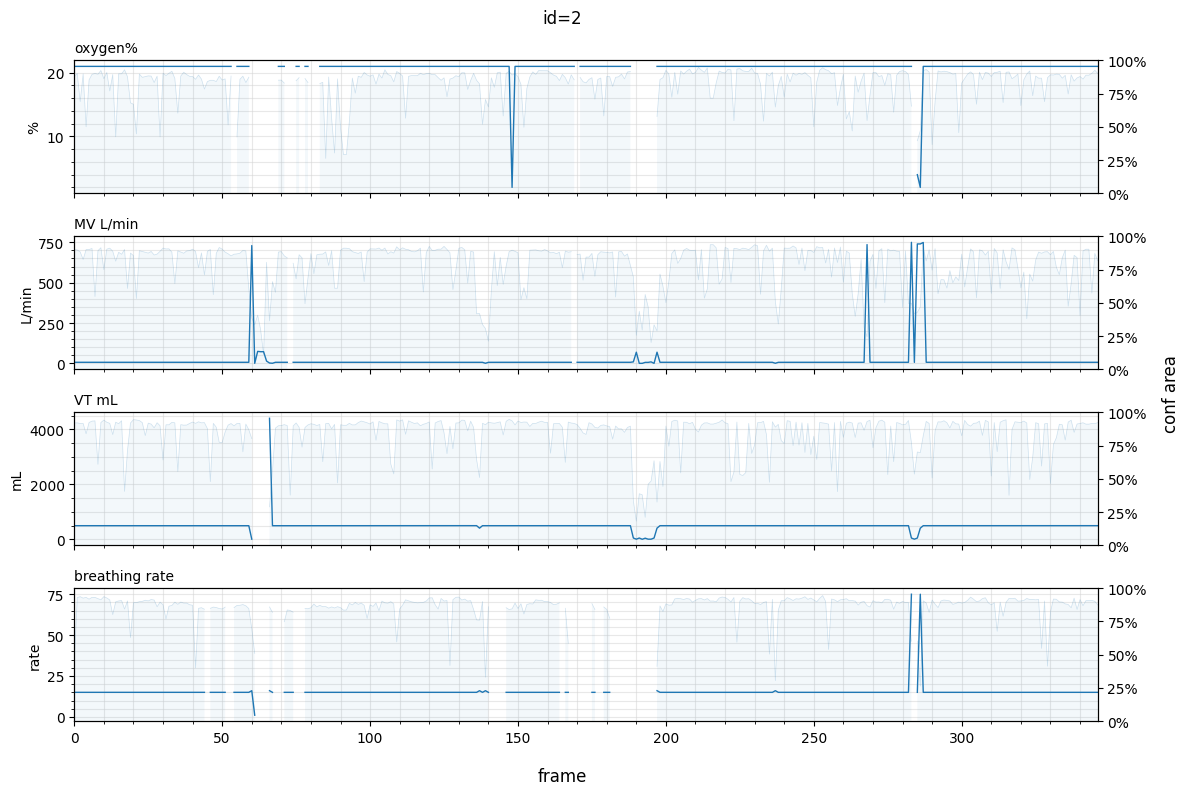

In [8]:
from monitrix.videoresult.resultsobject import VideoResults

video_results = VideoResults(results)

class_names = {
    0:"main screen",
    1:"oxygen%",
    2:"MV L/min",
    3:"VT mL",
    4:"breathing rate",
}
class_units = {
    1:"%",
    2:"L/min",
    3:"mL",
    4:"rate",
}
video_results.to_df().timeplot(class_names=class_names,class_units=class_units)

[<Figure size 1200x800 with 8 Axes>, <Figure size 1200x800 with 8 Axes>]

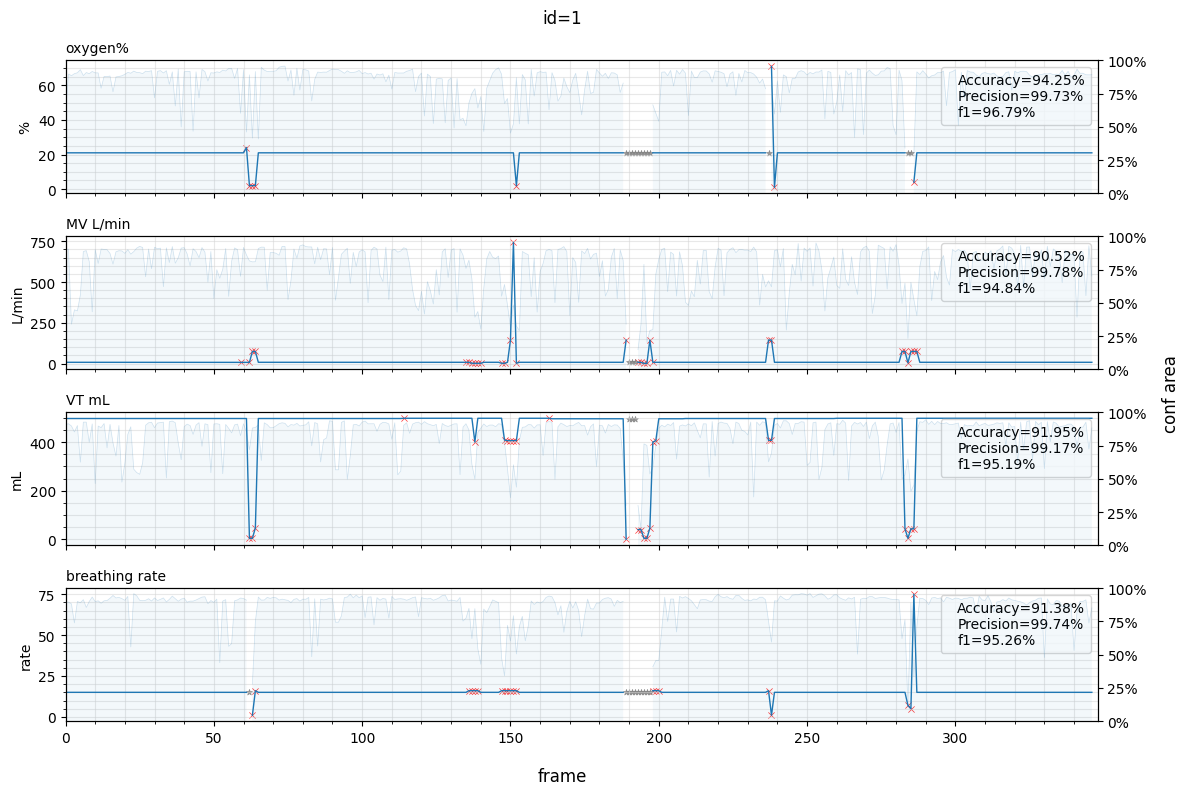

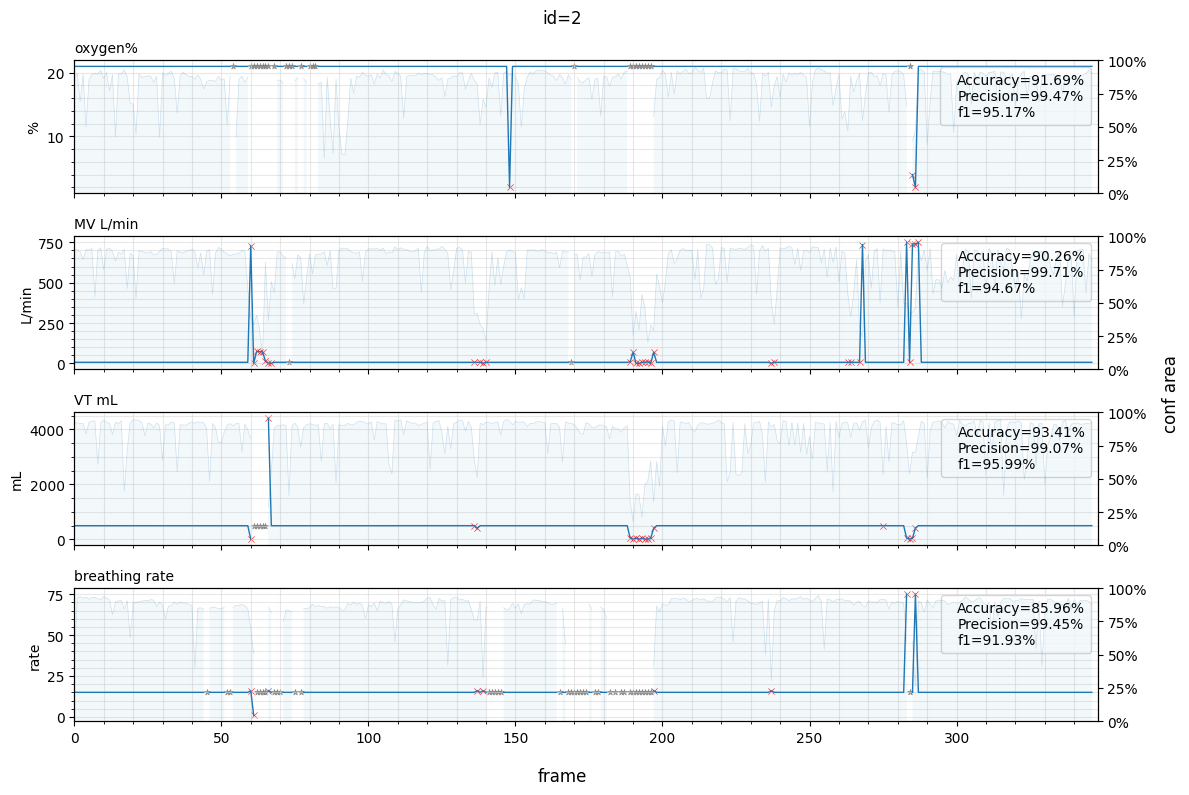

In [9]:
import pandas as pd
# 正解データ
def _get_true(
        annnotaion_path: Path,
        cls_mapper: dict[str, int],
        drop_value = "omit"
    ):
    _df = pd.read_excel(annnotaion_path)
    # チェック
    assert all(_df.columns == ["monitor","frame","oxygen%","MV L/min","VT mL","breathing rate","caution"])
    
    # クラス名を整数に変更
    _df = _df.rename(cls_mapper, axis=1)

    # cautionの空欄をFalseに
    _df["caution"] = _df["caution"].fillna(0.0).astype(bool)
    
    # ピボット解除
    _df = _df.melt(
        id_vars=["frame", "monitor", "caution"],
        var_name="class",
        value_name="true_value",
    )
    # 特定の値を除去
    _df = _df[_df["true_value"] != drop_value]
    _df["true_value"] = _df["true_value"].astype(float)

    # 名称変更とソート
    _df = _df.rename({"monitor": "monitor_id"}, axis=1)
    _df = _df.sort_values(["frame", "monitor_id", "class"]).reset_index(drop=True)

    return _df

file = Path(f"../../sample_data/{source.stem}.xlsx")
assert file.exists()
true_value = _get_true(file,{v:k for k,v in results[0].names.items()})
true_value = true_value[~true_value["caution"]]# caution==True除く
true_value = true_value.drop("caution",axis=1)

video_results = VideoResults(results)

d = video_results.to_df()

d = d.add_true(true_value, {0:2, 1:1})

d.timeplot(
    class_names=class_names,class_units=class_units,
    scores = {
        "accuracy":("Accuracy=", ".2%"),
        "precision_weighted":("Precision=", ".2%"),
        "f1_weighted":("f1=", ".2%"),
        }
    )



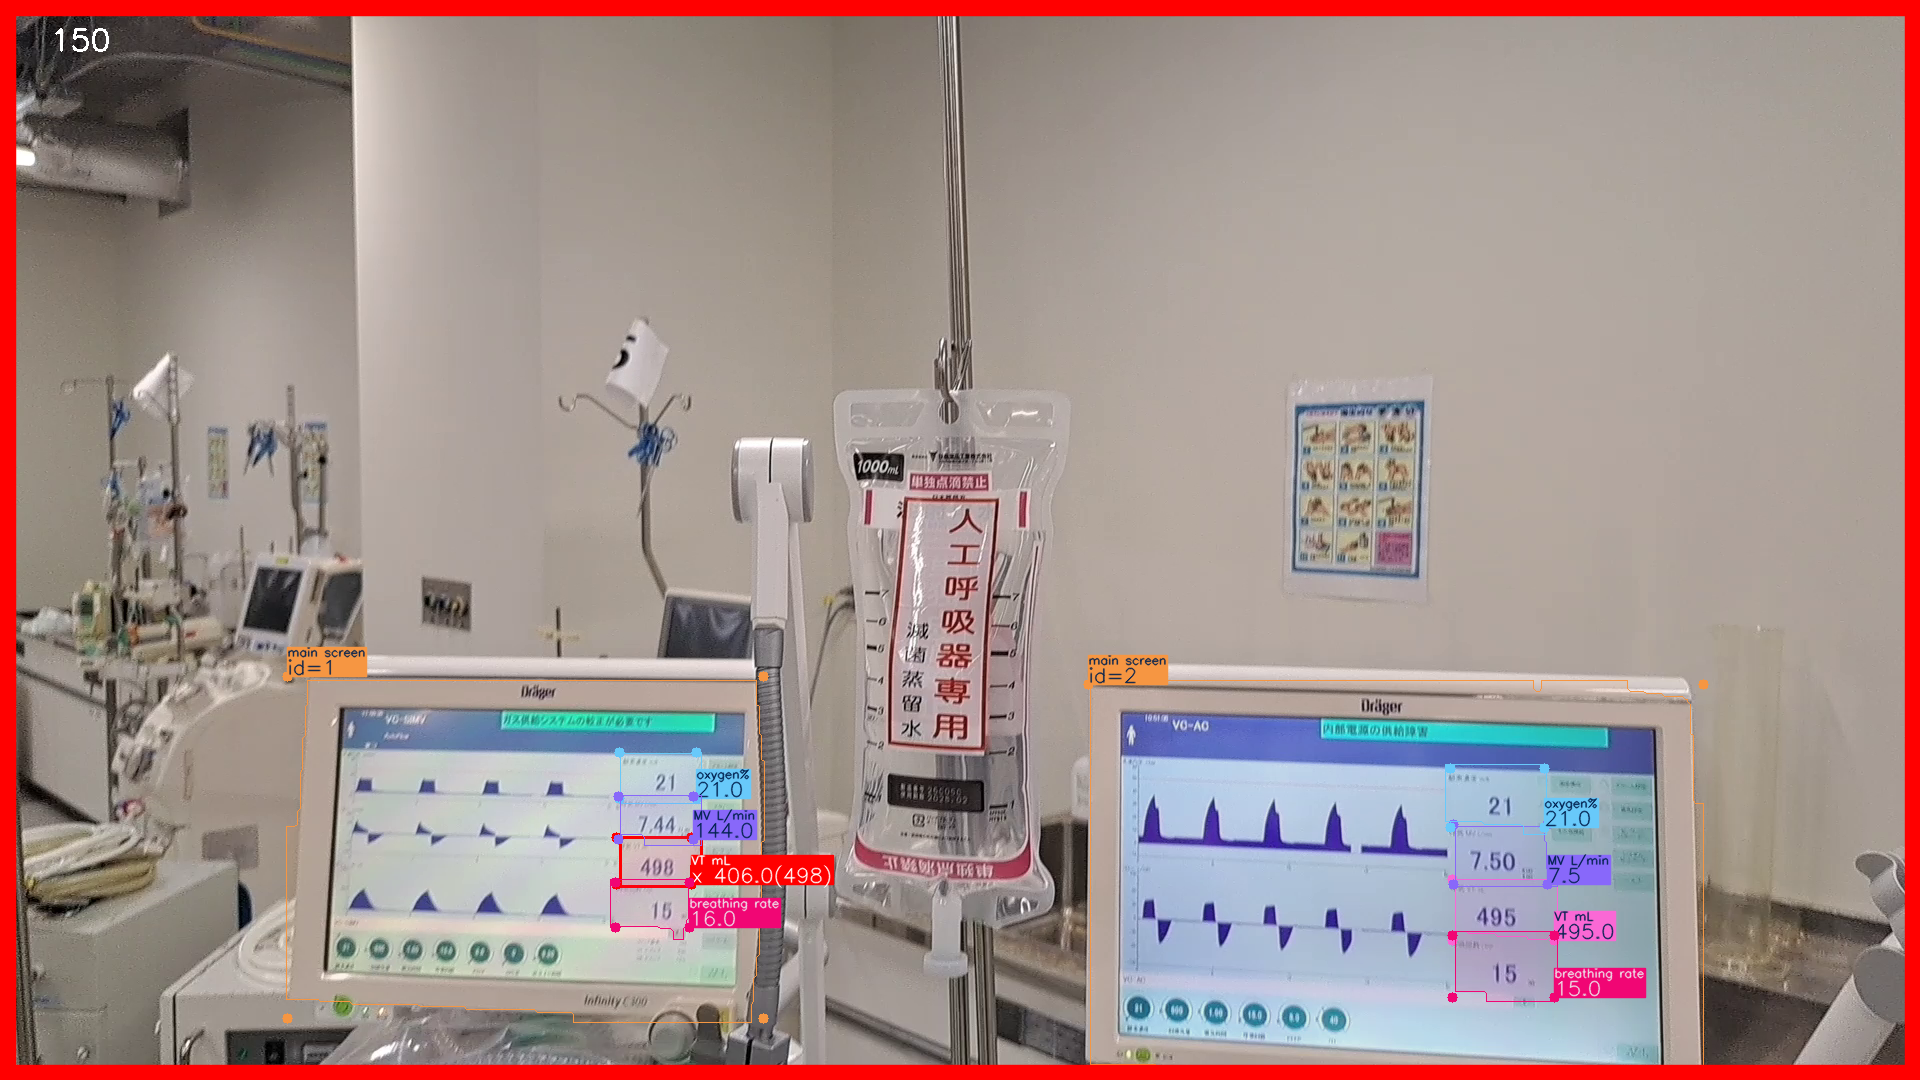

In [21]:
from monitrix.draw import plot
from PIL import Image

preset_colors = {
    0:("#F69642","#01204E"),
    1:("#68C9FA","#01204E"),
    2:("#8868FA","#01204E"),
    3:("#FA68D5","#01204E"),
    4:("#F10674","#EDE1E9"),
}
preset_classnames = {
    0:"main screen",
    1:"oxygen%",
    2:"MV L/min",
    3:"VT mL",
    4:"breathing rate",
}

trues = {
    5:498
}

k = 150
Image.fromarray(
    plot(
        video_results[k],
        class_names=preset_classnames,
        colors=preset_colors,
        trues=trues,
        cvt_rgb=True))

In [ ]:
# 正解と共にOCR結果動画を書き出し
trues = d[["frame","id","true_value"]].dropna(subset="id")
trues = {k:dict(zip(g["id"].astype(int),g["true_value"])) for k,g in trues.groupby(by="frame",group_keys=True)}

video_results.to_video("results.mp4",resize=0.5,trues=trues)

write frame: 100%|██████████| 347/347 [00:10<00:00, 32.57it/s]


In [23]:
# データフレーム
video_results.to_df()

,frame,is_monitor,monitor_id,id,object_conf,class,ocr_conf,pred_value
0,0,True,1.0,1,0.968262,0,NaN,NaN
1,0,True,2.0,2,0.967773,0,NaN,NaN
2,0,False,2.0,3,0.922363,4,0.470544,15.00
3,0,False,2.0,4,0.919434,3,0.999932,495.00
4,0,False,1.0,5,0.914062,3,0.993301,497.00
...,...,...,...,...,...,...,...,...
3420,346,False,1.0,9,0.920898,2,0.762135,7.44
3421,346,False,1.0,10,0.896484,4,0.950414,15.00
3422,346,False,2.0,7,0.898438,2,0.908282,7.49
3423,346,False,2.0,6,0.901855,1,1.000000,21.00


In [25]:
# metoric

d = video_results.to_df()
d = d.add_true(true_value, {0:2, 1:1})

m = d.metrics("monitor_id")
m

[metric(key=1), metric(key=2)]

In [26]:
m.scores()

{'total samples': 2788,
 'cm_tp': 2530,
 'cm_tn': 12,
 'cm_fp': 145,
 'cm_fn': 101,
 'accuracy_weighted': 0.9117647058823529,
 'accuracy_macro': 0.9117768748147417,
 'accuracy_micro': 0.9117647058823529,
 'precision_weighted': 0.945921107394794,
 'precision_macro': 0.945911149630955,
 'precision_micro': 0.9457943925233645,
 'recall_weighted': 0.9617215344365315,
 'recall_macro': 0.961745635477887,
 'recall_micro': 0.9616115545419992,
 'f1_weighted': 0.953609192975785,
 'f1_macro': 0.9536159834845661,
 'f1_micro': 0.9536373916321146}